# Visual Representation Analysis: BioCLIP v1 vs BioCLIP 2

This notebook analyses the visual representation quality of BioCLIP v1 and BioCLIP 2 on the DiopSIS readable subset.

Three analyses are performed in parallel for both models:

1. **k-NN classification** — 3-fold cross-validation with cosine metric, k=5, on L2-normalised embeddings. Establishes whether visual features alone (without text-based classification) enable accurate order prediction.

2. **Per-class silhouette scores** — measures how well each order clusters in the embedding space relative to neighbouring classes.

3. **Pairwise centroid distances** — heatmap of cosine distances between class centroids, revealing which orders are visually close in the embedding space.

4. **Neighbour purity distribution** — for each order, the distribution of how many of the 5 nearest neighbours share the same class label.

All analyses are performed on the L2-normalised 512-dimensional (v1) or 768-dimensional (v2) embeddings. Cross-validation uses 3 stratified folds with `random_state=0` for consistency with other experiments in this thesis.

**Output:** all figures are saved to `results/figures/` as PDF for publication.

In [38]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, silhouette_samples
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cdist

# ---------------------------------------------------------------
# Publication styling: Times New Roman 9pt, minimal decoration
# ---------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",           # falls back gracefully if Times not installed
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.6,
    "figure.dpi": 150,
})

# ---------------------------------------------------------------
# Paths and configuration
# ---------------------------------------------------------------
BASE = Path("/Users/krolik/Documents/python_/MScThesis/diopsis_apollo_all/md")
FIG_DIR = Path("/Users/krolik/Documents/python_/MScThesis/diopsis_apollo_all/md/thesis_results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "meta_path": BASE / "lg_met_readable.csv",
    "embeddings": {
        "BioCLIP v1": BASE / "embeddings" / "bioclip_v1_embeddings_v03.npz",
        "BioCLIP 2":  BASE / "embeddings" / "bioclip_v2_embeddings_v03.npz",
    },
    "k_folds": 3,          # consistent with other CV experiments in the thesis
    "k_neighbors": 5,      # standard k for k-NN
    "random_state": 0,
    "min_class_size": 50,  # for reporting macro metrics restricted to well-supported classes
}

## Helper functions

In [39]:
def crop_id_from_path(p):
    """Strip file extension and directory to get crop ID."""
    return Path(p).stem


def split_on_number(s):
    """Split identifier at the first numeric token; return (prefix_set, remainder)."""
    parts = s.split("_")
    for i, p in enumerate(parts):
        if p and p[0].isdigit():
            return set(parts[:i]), "_".join(parts[i:])
    return set(parts), ""


def load_embeddings_and_align(emb_path, meta_df):
    """Load NPZ embeddings, align with metadata via crop_id, return X_aligned, y, df_merged."""
    npz = np.load(emb_path)
    paths = npz["paths"]
    X = npz["embeddings"].astype(np.float32)
    ids = np.array([crop_id_from_path(p) for p in paths])

    ids_df = pd.DataFrame({"crop_id_raw": ids})
    ids_df[["labels_set", "crop_id"]] = ids_df["crop_id_raw"].apply(
        lambda s: pd.Series(split_on_number(s))
    )
    ids_df = ids_df.drop(columns=["labels_set", "crop_id_raw"])
    ids_df["row_idx"] = np.arange(len(ids))

    # Meta preparation
    meta = meta_df[["image_id", "label"]].copy()
    meta = meta.rename(columns={"label": "order"})
    meta["crop_id"] = meta["image_id"].str[:-4]

    # Merge and align
    df_merged = ids_df.merge(meta, on="crop_id", how="left")
    df_merged = df_merged.dropna(subset=["order"]).reset_index(drop=True)

    X_aligned = X[df_merged["row_idx"].values]
    y = np.asarray(df_merged["order"].values)

    # L2-normalise for cosine geometry
    X_aligned = normalize(X_aligned, norm="l2", axis=1)

    return X_aligned, y, df_merged


def knn_cross_validation(X, y, k_folds, k_neighbors, random_state):
    """3-fold stratified CV with k-NN. Returns per-fold reports and aggregate report.

    Returns:
        y_pred: concatenated predictions (for confusion matrix, per-class inspection)
        per_fold_reports: list of classification_report dicts, one per fold
        aggregate_report: classification_report on all concatenated predictions
    """
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)
    y_pred = np.empty_like(y)
    per_fold_reports = []

    for tr_idx, te_idx in skf.split(X, y):
        knn = KNeighborsClassifier(n_neighbors=k_neighbors, metric="cosine", n_jobs=-1)
        knn.fit(X[tr_idx], y[tr_idx])
        fold_pred = knn.predict(X[te_idx])
        y_pred[te_idx] = fold_pred

        # Per-fold report on this fold's val set
        fold_report = classification_report(
            y[te_idx], fold_pred, output_dict=True, zero_division=0
        )
        per_fold_reports.append(fold_report)

    aggregate_report = classification_report(y, y_pred, output_dict=True, zero_division=0)
    return y_pred, per_fold_reports, aggregate_report


def aggregate_per_fold_metrics(per_fold_reports, classnames):
    """Compute mean ± SD across folds for per-class F1, precision, recall.

    Returns:
        per_class_df: DataFrame with columns f1_mean, f1_std, precision_mean, precision_std,
                      recall_mean, recall_std, support_total (across folds)
    """
    rows = []
    for cls_name in classnames:
        f1_scores = []
        precisions = []
        recalls = []
        total_support = 0
        for report in per_fold_reports:
            if cls_name in report:
                f1_scores.append(report[cls_name]["f1-score"])
                precisions.append(report[cls_name]["precision"])
                recalls.append(report[cls_name]["recall"])
                total_support += report[cls_name]["support"]

        if f1_scores:
            rows.append({
                "class": cls_name,
                "support_total": int(total_support),
                "f1_mean": round(np.mean(f1_scores), 4),
                "f1_std": round(np.std(f1_scores, ddof=1), 4),
                "precision_mean": round(np.mean(precisions), 4),
                "precision_std": round(np.std(precisions, ddof=1), 4),
                "recall_mean": round(np.mean(recalls), 4),
                "recall_std": round(np.std(recalls, ddof=1), 4),
            })
    return pd.DataFrame(rows)


def aggregate_headline_metrics(per_fold_reports, classnames, min_class_size=50):
    """Compute weighted F1, macro F1 (all), macro F1 (n≥50) per fold, then mean ± SD.

    Returns:
        dict with weighted_f1_mean/std, macro_f1_all_mean/std, macro_f1_n50_mean/std,
        Hemiptera_f1_mean/std, Coleoptera_f1_mean/std
    """
    weighted_f1s = []
    macro_all_f1s = []
    macro_n50_f1s = []
    hemi_f1s = []
    cole_f1s = []

    # Determine eligible classes based on total support across folds
    total_support_per_class = {}
    for cls in classnames:
        total = sum(r.get(cls, {}).get("support", 0) for r in per_fold_reports)
        total_support_per_class[cls] = total
    eligible = [c for c in classnames if total_support_per_class.get(c, 0) >= min_class_size]

    for report in per_fold_reports:
        weighted_f1s.append(report["weighted avg"]["f1-score"])
        macro_all_f1s.append(report["macro avg"]["f1-score"])

        # Macro F1 restricted to eligible classes
        eligible_f1s = [report[c]["f1-score"] for c in eligible if c in report]
        macro_n50_f1s.append(np.mean(eligible_f1s) if eligible_f1s else 0)

        hemi_f1s.append(report.get("Hemiptera", {}).get("f1-score", 0))
        cole_f1s.append(report.get("Coleoptera", {}).get("f1-score", 0))

    return {
        "weighted_f1_mean": round(np.mean(weighted_f1s), 4),
        "weighted_f1_std":  round(np.std(weighted_f1s, ddof=1), 4),
        "macro_f1_all_mean": round(np.mean(macro_all_f1s), 4),
        "macro_f1_all_std":  round(np.std(macro_all_f1s, ddof=1), 4),
        "macro_f1_n50_mean": round(np.mean(macro_n50_f1s), 4),
        "macro_f1_n50_std":  round(np.std(macro_n50_f1s, ddof=1), 4),
        "Hemiptera_f1_mean": round(np.mean(hemi_f1s), 4),
        "Hemiptera_f1_std":  round(np.std(hemi_f1s, ddof=1), 4),
        "Coleoptera_f1_mean": round(np.mean(cole_f1s), 4),
        "Coleoptera_f1_std":  round(np.std(cole_f1s, ddof=1), 4),
    }


def compute_per_class_silhouette(X, y):
    """Cosine silhouette per class, returned as Series indexed by class name.
    
    Note: silhouette is a global structural property, not a validation metric;
    it is computed once on the full dataset, not per fold.
    """
    sil_samples = silhouette_samples(X, y, metric="cosine")
    return pd.Series(sil_samples).groupby(y).mean().round(3).rename("silhouette")


def compute_centroid_distances(X, y):
    """Pairwise cosine distances between class centroids. Returns labelled DataFrame."""
    centroids = pd.DataFrame(X).groupby(y).mean()
    # Order by class support (largest first) for consistent axes
    class_counts = pd.Series(y).value_counts()
    ordering = [c for c in class_counts.index if c in centroids.index]
    centroids = centroids.loc[ordering]

    dist_matrix = cdist(centroids.values, centroids.values, metric="cosine")
    return pd.DataFrame(dist_matrix, index=centroids.index, columns=centroids.index)


def compute_neighbour_purity(X, y, k_neighbors=5):
    """For each point, count how many of its k nearest neighbours share the same class label."""
    from sklearn.neighbors import NearestNeighbors
    
    # Ensure y is a proper numpy array (not Arrow-backed)
    y = np.asarray(y)
    
    nn = NearestNeighbors(n_neighbors=k_neighbors + 1, metric="cosine", n_jobs=-1)
    nn.fit(X)
    _, indices = nn.kneighbors(X)
    # Exclude self (first neighbour is always the point itself)
    neighbour_labels = y[indices[:, 1:]]
    same_class = (neighbour_labels == y[:, None]).sum(axis=1)
    return same_class  # array of shape (N,), values 0..k

## Load metadata and embeddings for both models

In [40]:
# Load shared metadata once
meta_df = pd.read_csv(CONFIG["meta_path"])
print(f"Metadata rows: {len(meta_df)}")

# Load embeddings for both models
results = {}
for model_name, emb_path in CONFIG["embeddings"].items():
    print(f"\nLoading {model_name} from {emb_path.name}...")
    X, y, df_merged = load_embeddings_and_align(emb_path, meta_df)
    results[model_name] = {
        "X": X,
        "y": y,
        "df_merged": df_merged,
    }
    print(f"  Aligned samples: {len(X)}")
    print(f"  Embedding dim:   {X.shape[1]}")
    print(f"  Classes:         {len(np.unique(y))}")

Metadata rows: 39788

Loading BioCLIP v1 from bioclip_v1_embeddings_v03.npz...
  Aligned samples: 39788
  Embedding dim:   512
  Classes:         14

Loading BioCLIP 2 from bioclip_v2_embeddings_v03.npz...
  Aligned samples: 39788
  Embedding dim:   768
  Classes:         14


## Analysis 1: k-NN cross-validation

3-fold stratified CV with k=5, cosine metric, on L2-normalised embeddings. Consistent with all other CV experiments in this thesis.

In [41]:
for model_name in results:
    print(f"\n{'='*60}\n{model_name}: {CONFIG['k_folds']}-fold k-NN (k={CONFIG['k_neighbors']})\n{'='*60}")

    X = results[model_name]["X"]
    y = results[model_name]["y"]

    # Run CV with per-fold reports
    y_pred, per_fold_reports, aggregate_report = knn_cross_validation(
        X, y, CONFIG["k_folds"], CONFIG["k_neighbors"], CONFIG["random_state"]
    )

    # Classnames (union across folds)
    classnames = sorted(np.unique(y).tolist())

    # Per-class metrics with mean ± SD
    per_class_df = aggregate_per_fold_metrics(per_fold_reports, classnames)

    # Silhouette per class (computed once on full dataset, not per-fold — it's a
    # global structural property, not a validation metric)
    sil_per_class = compute_per_class_silhouette(X, y)
    per_class_df = per_class_df.merge(
        sil_per_class.rename("silhouette").reset_index().rename(columns={"index": "class"}),
        on="class", how="left"
    )

    # Store results
    results[model_name]["knn_predictions"] = y_pred
    results[model_name]["per_fold_reports"] = per_fold_reports
    results[model_name]["aggregate_report"] = aggregate_report
    results[model_name]["per_class"] = per_class_df

    # Save per-class CSV
    fname = f"knn3_{model_name.replace(' ', '_').lower()}_per_class.csv"
    per_class_df.to_csv(BASE / "embeddings" / fname, index=False)
    print(f"Saved: {fname}")
    print(per_class_df.head(15).to_string(index=False))


BioCLIP v1: 3-fold k-NN (k=5)


/Users/krolik/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/Users/krolik/anaconda3/envs/thesis/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/krolik/anaconda3/envs/thesis/lib/python3.11/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved: knn3_bioclip_v1_per_class.csv
        class  support_total  f1_mean  f1_std  precision_mean  precision_std  recall_mean  recall_std  silhouette
      Araneae            564   0.9614  0.0173          0.9942         0.0058       0.9309      0.0276       0.522
    Blattodea             23   0.8746  0.0522          1.0000         0.0000       0.7798      0.0844       0.183
   Coleoptera           1143   0.7117  0.0235          0.8759         0.0266       0.5993      0.0211      -0.027
      Diptera          31914   0.9746  0.0008          0.9556         0.0006       0.9945      0.0017      -0.039
    Hemiptera            775   0.5953  0.0188          0.8839         0.0360       0.4490      0.0159       0.023
  Hymenoptera           3326   0.8962  0.0052          0.9451         0.0133       0.8521      0.0015       0.049
      Ixodida              1   0.0000     NaN          0.0000            NaN       0.0000         NaN       0.000
  Lepidoptera           1744   0.9747  0.0023      

/Users/krolik/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/Users/krolik/anaconda3/envs/thesis/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/krolik/anaconda3/envs/thesis/lib/python3.11/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved: knn3_bioclip_2_per_class.csv
        class  support_total  f1_mean  f1_std  precision_mean  precision_std  recall_mean  recall_std  silhouette
      Araneae            564   0.9829  0.0070          0.9965         0.0061       0.9699      0.0187       0.524
    Blattodea             23   0.9107  0.0778          0.9259         0.1283       0.9167      0.1443       0.458
   Coleoptera           1143   0.8499  0.0109          0.9330         0.0073       0.7804      0.0154       0.018
      Diptera          31914   0.9847  0.0008          0.9755         0.0015       0.9941      0.0005       0.081
    Hemiptera            775   0.8130  0.0234          0.9090         0.0199       0.7355      0.0279       0.074
  Hymenoptera           3326   0.9351  0.0038          0.9578         0.0045       0.9134      0.0059       0.142
      Ixodida              1   0.0000     NaN          0.0000            NaN       0.0000         NaN       0.000
  Lepidoptera           1744   0.9855  0.0041       

In [42]:
# ================================================================
# Save k-NN results as single formatted table (mean ± SD)
# Per-order rows first, aggregate rows at bottom
# ================================================================

def format_mean_std(mean, std, decimals=4):
    """Format value as 'mean ± SD' string. Handle NaN gracefully."""
    if pd.isna(mean) or pd.isna(std):
        return "—"
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


# ---------------------------------------------------------------
# Per-order rows (sorted by support, largest first)
# ---------------------------------------------------------------
v1_per_class = results["BioCLIP v1"]["per_class"].set_index("class")
v2_per_class = results["BioCLIP 2"]["per_class"].set_index("class")

class_ordering = sorted(v1_per_class.index.tolist())

table_rows = []
for cls in class_ordering:
    table_rows.append({
        "Order": cls,
        "n": int(v1_per_class.loc[cls, "support_total"]),
        "BioCLIP v1 F1": format_mean_std(
            v1_per_class.loc[cls, "f1_mean"], v1_per_class.loc[cls, "f1_std"]
        ),
        "BioCLIP 2 F1": format_mean_std(
            v2_per_class.loc[cls, "f1_mean"], v2_per_class.loc[cls, "f1_std"]
        ),
    })

# ---------------------------------------------------------------
# Aggregate rows (macro all, macro n>=50, weighted)
# ---------------------------------------------------------------
v1_head = summary_df[summary_df["model"] == "BioCLIP v1"].iloc[0]
v2_head = summary_df[summary_df["model"] == "BioCLIP 2"].iloc[0]

# Total n for aggregate rows (sum across all classes)
total_n = sum(int(v1_per_class.loc[c, "support_total"]) for c in class_ordering)
# For n>=50 macro, use only eligible classes
n_eligible = sum(int(v1_per_class.loc[c, "support_total"]) 
                 for c in class_ordering 
                 if v1_per_class.loc[c, "support_total"] >= CONFIG["min_class_size"])

# Separator row (empty) for visual separation between per-order and aggregates
table_rows.append({
    "Order": "",
    "n": "",
    "BioCLIP v1 F1": "",
    "BioCLIP 2 F1": "",
})

# Aggregate rows
aggregates = [
    ("Macro avg (all 14)", total_n, "macro_f1_all"),
    (f"Macro avg (n ≥ {CONFIG['min_class_size']})", n_eligible, "macro_f1_n50"),
    ("Weighted avg", total_n, "weighted_f1"),
]

for label, n, key in aggregates:
    table_rows.append({
        "Order": label,
        "n": n,
        "BioCLIP v1 F1": format_mean_std(v1_head[f"{key}_mean"], v1_head[f"{key}_std"]),
        "BioCLIP 2 F1": format_mean_std(v2_head[f"{key}_mean"], v2_head[f"{key}_std"]),
    })

# ---------------------------------------------------------------
# Build DataFrame and save
# ---------------------------------------------------------------
formatted_table = pd.DataFrame(table_rows)

csv_path = FIG_DIR / "knn_results_formatted.csv"
formatted_table.to_csv(csv_path, index=False)
print(f"Saved: {csv_path.name}\n")

# ---------------------------------------------------------------
# Print table
# ---------------------------------------------------------------
print("=" * 72)
print("  k-NN CLASSIFICATION RESULTS (3-fold CV, k=5, cosine metric)")
print("  Values: F1 mean ± SD across folds")
print("=" * 72)
print(formatted_table.to_string(index=False))


Saved: knn_results_formatted.csv

  k-NN CLASSIFICATION RESULTS (3-fold CV, k=5, cosine metric)
  Values: F1 mean ± SD across folds
             Order     n   BioCLIP v1 F1    BioCLIP 2 F1
           Araneae   564 0.9614 ± 0.0173 0.9829 ± 0.0070
         Blattodea    23 0.8746 ± 0.0522 0.9107 ± 0.0778
        Coleoptera  1143 0.7117 ± 0.0235 0.8499 ± 0.0109
           Diptera 31914 0.9746 ± 0.0008 0.9847 ± 0.0008
         Hemiptera   775 0.5953 ± 0.0188 0.8130 ± 0.0234
       Hymenoptera  3326 0.8962 ± 0.0052 0.9351 ± 0.0038
           Ixodida     1               —               —
       Lepidoptera  1744 0.9747 ± 0.0023 0.9855 ± 0.0041
         Mecoptera    34 0.2534 ± 0.0759 0.4827 ± 0.1637
        Neuroptera   115 0.4206 ± 0.0836 0.5976 ± 0.0917
        Orthoptera     8 1.0000 ± 0.0000 1.0000 ± 0.0000
        Plecoptera    54 0.9231 ± 0.0430 0.9170 ± 0.0072
     Raphidioptera     2 0.0000 ± 0.0000 0.0000 ± 0.0000
       Trichoptera    85 0.9230 ± 0.0204 0.9122 ± 0.0180
             

## Figure 1: Pairwise centroid distances (side-by-side heatmap)

Cosine distances between class centroids. Darker cells indicate small distances (classes close in the embedding space); lighter cells indicate large distances (classes well-separated).

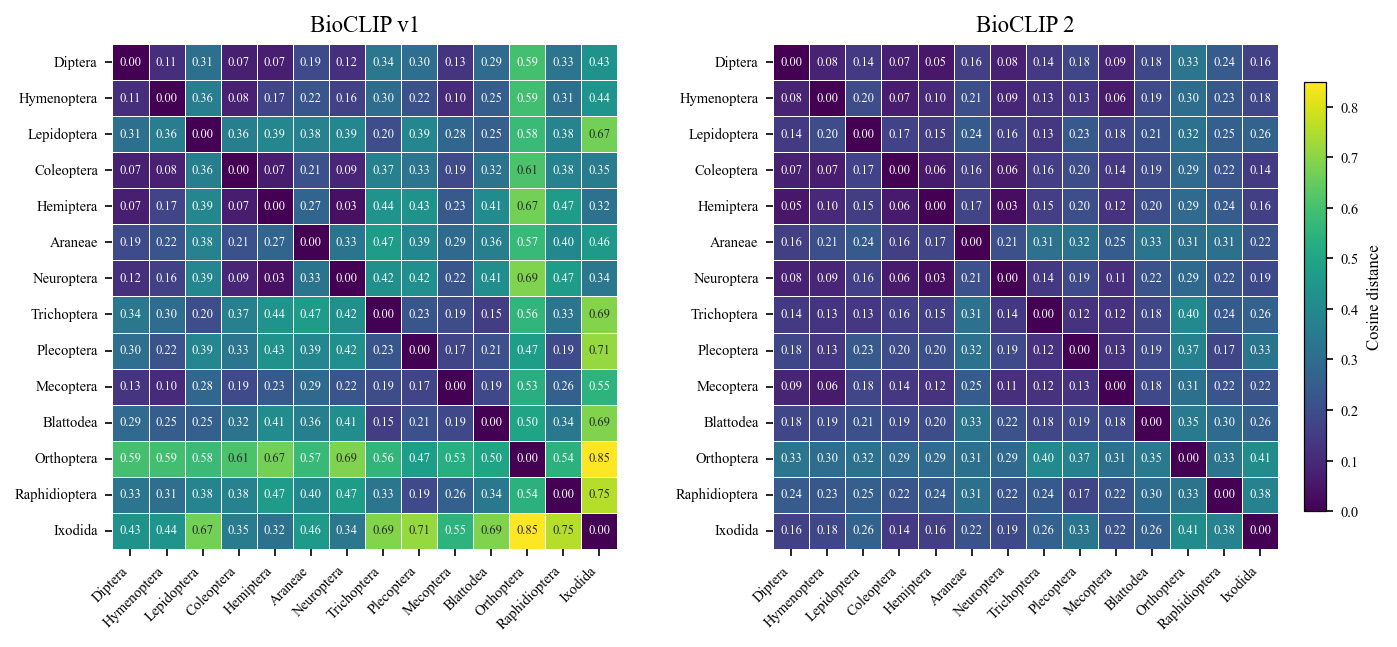

In [43]:
# Compute distance matrices for both models
dist_matrices = {}
for model_name in results:
    X = results[model_name]["X"]
    y = results[model_name]["y"]
    dist_matrices[model_name] = compute_centroid_distances(X, y)

# Compute shared vmin/vmax for comparable colour scale
all_values = np.concatenate([dm.values.flatten() for dm in dist_matrices.values()])
# Exclude diagonal (zeros) from vmin computation
off_diag = all_values[all_values > 0]
vmin_shared = off_diag.min()
vmax_shared = all_values.max()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), constrained_layout=True)

for ax, (model_name, dist_df) in zip(axes, dist_matrices.items()):
    sns.heatmap(
        dist_df,
        annot=True, fmt=".2f",
        cmap= "viridis", #"Greys_r",                    # reversed: dark = small distance, light = large
        vmin=vmin_shared, vmax=vmax_shared,
        cbar=False,                        # shared colorbar added separately
        square=True,
        linewidths=0.3, linecolor="white",
        annot_kws={"fontsize": 6},
        ax=ax,
    )
    ax.set_title(model_name, pad=6)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

# Shared colorbar
cbar = fig.colorbar(
    axes[-1].collections[0], ax=axes, orientation="vertical",
    fraction=0.02, pad=0.02, shrink=0.85,
)
cbar.set_label("Cosine distance", fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.savefig(FIG_DIR / "bioclip_v1_v2_pairwise_distances.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "bioclip_v1_v2_pairwise_distances.png", bbox_inches="tight", dpi=300)
plt.show()

## Figure 2: Neighbour purity distribution (side-by-side stacked bars)

For each order, the distribution of how many of its 5 nearest neighbours share the same class label. Higher share of "5/5" indicates a well-clustered class.

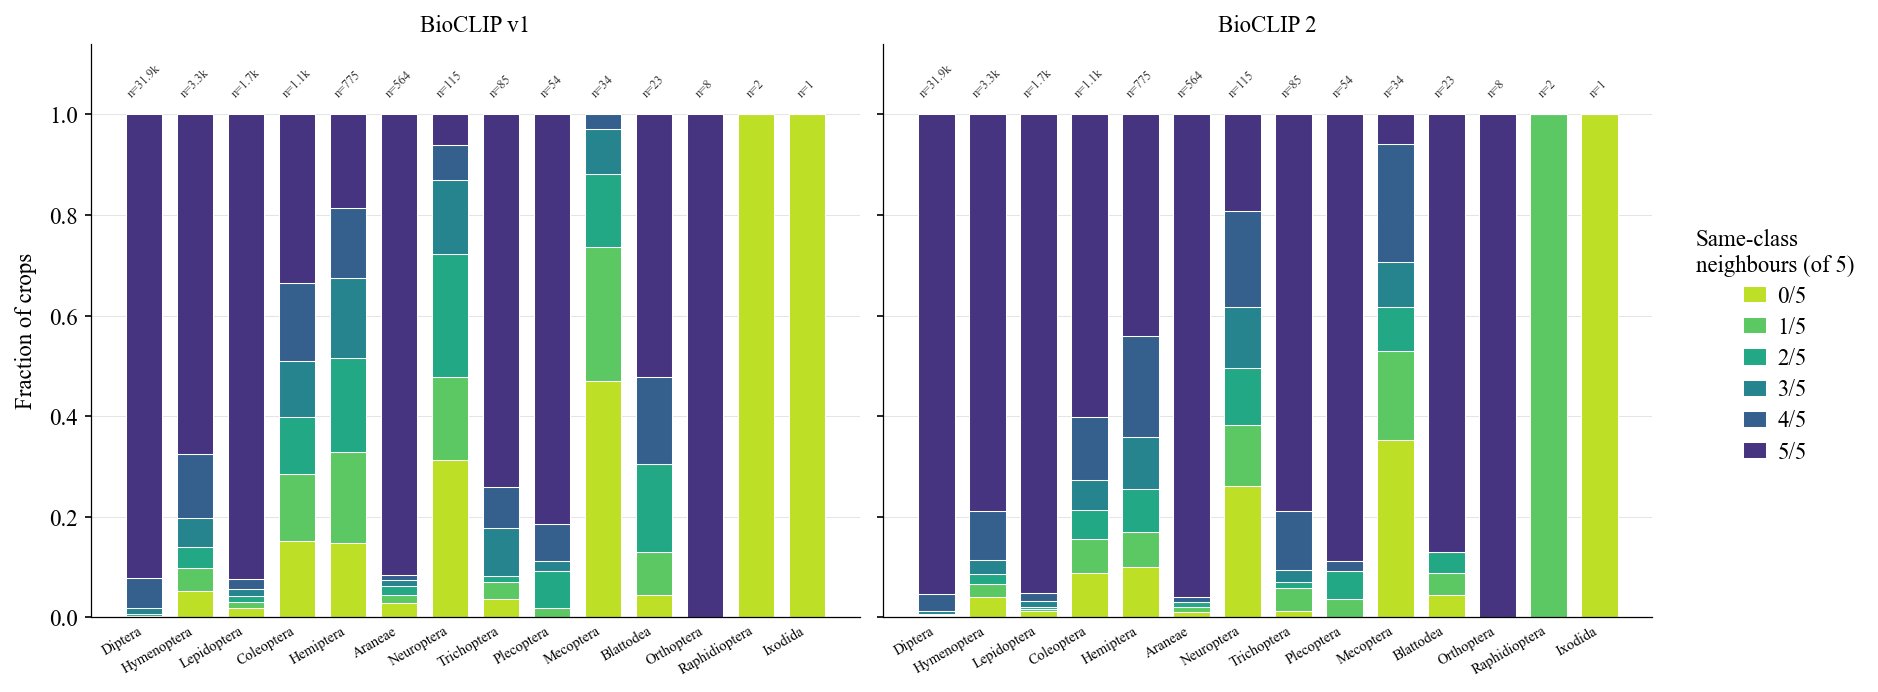

In [44]:
# Computing neighbour purity for both models
purity_data = {}
for model_name in results:
    X = results[model_name]["X"]
    y = results[model_name]["y"]
    same_class_counts = compute_neighbour_purity(X, y, k_neighbors=CONFIG["k_neighbors"])

    purity_df = pd.DataFrame({"order": y, "n_same": same_class_counts})
    purity_data[model_name] = purity_df

# Using shared class ordering (by size, largest first) for both plots
shared_ordering = pd.Series(list(results.values())[0]["y"]).value_counts().index.tolist()

# Helper: compact n formatting
def fmt_n(n):
    if n >= 1000:
        return f"{n/1000:.1f}k"
    return str(n)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.5), constrained_layout=True, sharey=True)

cmap = plt.cm.viridis_r
colors = cmap(np.linspace(0.1, 0.85, CONFIG["k_neighbors"] + 1))

for ax, (model_name, purity_df) in zip(axes, purity_data.items()):
    # Build fraction table
    pivot = purity_df.groupby(["order", "n_same"]).size().unstack(fill_value=0)
    for i in range(CONFIG["k_neighbors"] + 1):
        if i not in pivot.columns:
            pivot[i] = 0
    pivot = pivot[list(range(CONFIG["k_neighbors"] + 1))].loc[shared_ordering]
    pivot = pivot.div(pivot.sum(axis=1), axis=0)

    class_n = purity_df["order"].value_counts().loc[shared_ordering]

    # Stacked bars
    bottom = np.zeros(len(shared_ordering))
    for n_same in range(CONFIG["k_neighbors"] + 1):
        heights = pivot[n_same].values
        ax.bar(
            shared_ordering, heights, bottom=bottom,
            color=colors[n_same],
            edgecolor="white", linewidth=0.5,
            label=f"{n_same}/{CONFIG['k_neighbors']}",
            width=0.72,
        )
        bottom += heights

    # Annotating with class size — compact format + 45° rotation
    for i, cls in enumerate(shared_ordering):
        n = class_n[cls]
        ax.text(
            i, 1.03, f"n={fmt_n(n)}",
            ha="center", va="bottom", fontsize=6, color="#333333",
            rotation=45,
        )

    ax.set_title(model_name, pad=6)
    ax.set_ylim(0, 1.14)  # Extra room for rotated n labels
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="x", length=0, pad=3)
    ax.tick_params(axis="y", length=3, pad=3)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)
    ax.yaxis.grid(True, color="#e5e5e5", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Fraction of crops", labelpad=6)

# Shared legend on the right
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title=f"Same-class\nneighbours (of {CONFIG['k_neighbors']})",
    bbox_to_anchor=(1.01, 0.5), loc="center left",
    frameon=False, handlelength=1.0, handletextpad=0.5, labelspacing=0.4,
)

plt.savefig(FIG_DIR / "bioclip_v1_v2_neighbour_purity.png", bbox_inches="tight", dpi=300)
plt.savefig(FIG_DIR / "bioclip_v1_v2_neighbour_purity.pdf", bbox_inches="tight")
plt.show()

## Summary comparison

The k-NN classification performance and clustering statistics indicate whether BioCLIP 2's larger backbone and expanded pretraining translate into stronger downstream visual representations for this task.

In [45]:
summary_rows = []
for model_name in results:
    per_fold_reports = results[model_name]["per_fold_reports"]
    classnames = sorted(np.unique(results[model_name]["y"]).tolist())

    headline = aggregate_headline_metrics(
        per_fold_reports, classnames, min_class_size=CONFIG["min_class_size"]
    )
    headline["model"] = model_name
    summary_rows.append(headline)

# Reorder columns for readability: model, then metrics with mean before std
summary_df = pd.DataFrame(summary_rows)
column_order = [
    "model",
    "weighted_f1_mean", "weighted_f1_std",
    "macro_f1_all_mean", "macro_f1_all_std",
    "macro_f1_n50_mean", "macro_f1_n50_std",
    "Hemiptera_f1_mean", "Hemiptera_f1_std",
    "Coleoptera_f1_mean", "Coleoptera_f1_std",
]
summary_df = summary_df[column_order]
summary_df.to_csv(FIG_DIR / "knn_comparison_summary.csv", index=False)

print("k-NN comparison summary (mean ± SD across 3 folds):")
print(summary_df.to_string(index=False))

# Also print in a reader-friendly "mean ± std" format
print("\nReader-friendly format:")
for _, row in summary_df.iterrows():
    print(f"\n{row['model']}:")
    for metric in ["weighted_f1", "macro_f1_all", "macro_f1_n50", "Hemiptera_f1", "Coleoptera_f1"]:
        mean = row[f"{metric}_mean"]
        std = row[f"{metric}_std"]
        print(f"  {metric:20s}: {mean:.4f} ± {std:.4f}")

k-NN comparison summary (mean ± SD across 3 folds):
     model  weighted_f1_mean  weighted_f1_std  macro_f1_all_mean  macro_f1_all_std  macro_f1_n50_mean  macro_f1_n50_std  Hemiptera_f1_mean  Hemiptera_f1_std  Coleoptera_f1_mean  Coleoptera_f1_std
BioCLIP v1            0.9504           0.0015             0.7314            0.0047             0.8201            0.0105             0.5953            0.0188              0.7117             0.0235
 BioCLIP 2            0.9715           0.0013             0.7978            0.0101             0.8864            0.0086             0.8130            0.0234              0.8499             0.0109

Reader-friendly format:

BioCLIP v1:
  weighted_f1         : 0.9504 ± 0.0015
  macro_f1_all        : 0.7314 ± 0.0047
  macro_f1_n50        : 0.8201 ± 0.0105
  Hemiptera_f1        : 0.5953 ± 0.0188
  Coleoptera_f1       : 0.7117 ± 0.0235

BioCLIP 2:
  weighted_f1         : 0.9715 ± 0.0013
  macro_f1_all        : 0.7978 ± 0.0101
  macro_f1_n50        : 0.8864